## keterangan 
```Demographic Details
Age: The age of the students ranges from 15 to 18 years.
Gender: Gender of the students, where 0 represents Male and 1 represents Female.
Ethnicity: The ethnicity of the students, coded as follows:
0: Caucasian
1: African American
2: Asian
3: Other

ParentalEducation: The education level of the parents, coded as follows:
0: None
1: High School
2: Some College
3: Bachelor's
4: Higher

Study Habits
StudyTimeWeekly: Weekly study time in hours, ranging from 0 to 20.
Absences: Number of absences during the school year, ranging from 0 to 30.
Tutoring: Tutoring status, where 0 indicates No and 1 indicates Yes.
Parental Involvement
ParentalSupport: The level of parental support, coded as follows:
0: None
1: Low
2: Moderate
3: High
4: Very High

Extracurricular Activities
Extracurricular: Participation in extracurricular activities, where 0 indicates No and 1 indicates Yes.
Sports: Participation in sports, where 0 indicates No and 1 indicates Yes.
Music: Participation in music activities, where 0 indicates No and 1 indicates Yes.
Volunteering: Participation in volunteering, where 0 indicates No and 1 indicates Yes.

Academic Performance
GPA: Grade Point Average on a scale from 2.0 to 4.0, influenced by study habits, parental involvement, and extracurricular activities.
Target Variable: Grade Class
GradeClass: Classification of students' grades based on GPA:
0: 'A' (GPA >= 3.5)
1: 'B' (3.0 <= GPA < 3.5)
2: 'C' (2.5 <= GPA < 3.0)
3: 'D' (2.0 <= GPA < 2.5)
4: 'F' (GPA < 2.0)

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import streamlit as st
import pandas as pd


In [2]:
df = pd.read_csv('Student_performance_data _.csv')



## Rule
    JIKA GPA 'RENDAH', ABSEN TINGGI,

c:\Users\rrama\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


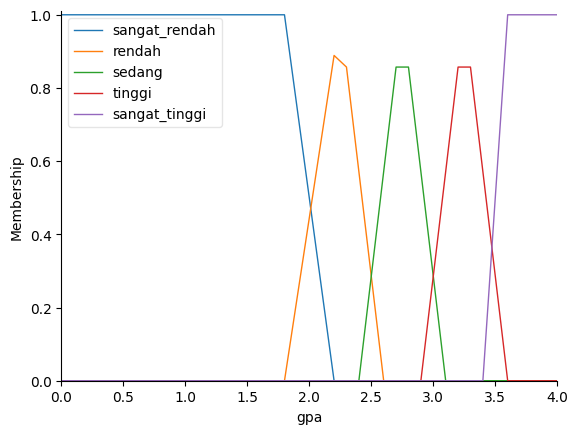

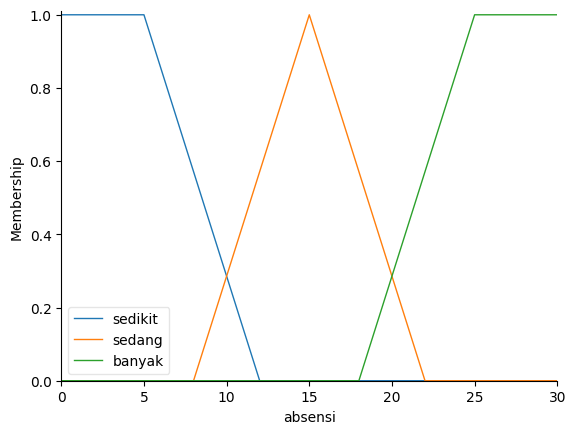

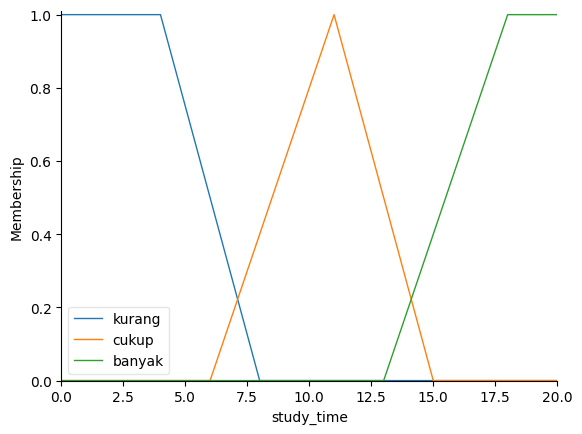

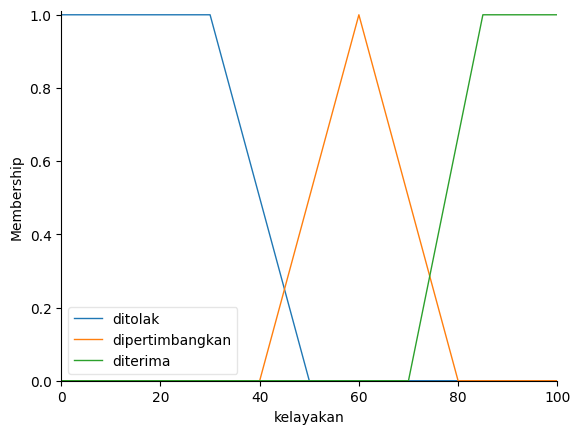

In [10]:
#Input
gpa = ctrl.Antecedent(np.arange(0,4.1,0.1),'gpa')
absences = ctrl.Antecedent(np.arange(0,31,1),'absensi')
study_time = ctrl.Antecedent(np.arange(0,21,1),'study_time')

#output 
kelayakan = ctrl.Consequent(np.arange(0,101,1), 'kelayakan')

#fungsi keanggotaan
# 0: 'A' (GPA >= 3.5)
# 1: 'B' (3.0 <= GPA < 3.5)
# 2: 'C' (2.5 <= GPA < 3.0)
# 3: 'D' (2.0 <= GPA < 2.5)
# 4: 'F' (GPA < 2.0)
gpa['sangat_rendah'] = fuzz.trapmf(gpa.universe, [0, 0, 1.8, 2.2])    # Rata di 0 sampai 1.8, lalu turun di 2.2
gpa['rendah']        = fuzz.trimf(gpa.universe, [1.8, 2.25, 2.6])     # Beririsan dengan sangat_rendah dan sedang
gpa['sedang']        = fuzz.trimf(gpa.universe, [2.4, 2.75, 3.1])     # Beririsan dengan rendah dan tinggi
gpa['tinggi']        = fuzz.trimf(gpa.universe, [2.9, 3.25, 3.6])     # Beririsan dengan sedang dan sangat_tinggi
gpa['sangat_tinggi'] = fuzz.trapmf(gpa.universe, [3.4, 3.6, 4.0, 4.0]) # Mulai naik di 3.4, flat mendatar dari 3.6 sampai 4.0


# 3. Fungsi Keanggotaan untuk ABSENSI (Cost: Semakin banyak absen, semakin buruk)
absences['sedikit']  = fuzz.trapmf(absences.universe, [0, 0, 5, 12])
absences['sedang']   = fuzz.trimf(absences.universe, [8, 15, 22])
absences['banyak']   = fuzz.trapmf(absences.universe, [18, 25, 30, 30])


# 4. Fungsi Keanggotaan untuk STUDY TIME (Benefit: Semakin lama belajar, semakin bagus)
study_time['kurang'] = fuzz.trapmf(study_time.universe, [0, 0, 4, 8])
study_time['cukup']  = fuzz.trimf(study_time.universe, [6, 11, 15])
study_time['banyak'] = fuzz.trapmf(study_time.universe, [13, 18, 20, 20])


# 5. Fungsi Keanggotaan untuk OUTPUT (Skor Kelayakan Beasiswa 0-100)
kelayakan['ditolak']         = fuzz.trapmf(kelayakan.universe, [0, 0, 30, 50])
kelayakan['dipertimbangkan'] = fuzz.trimf(kelayakan.universe, [40, 60, 80])
kelayakan['diterima']        = fuzz.trapmf(kelayakan.universe, [70, 85, 100, 100])

# Catatan: Anda bisa melihat visualisasi grafiknya dengan cara:
gpa.view()
absences.view()
study_time.view()
kelayakan.view()